In [36]:
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [37]:
import os
path = "/kaggle/input/brazilian-ecommerce"
print("Files in the path:")
print(os.listdir(path))

Files in the path:
['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [38]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [39]:
orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
geolocation = pd.read_csv(f"{path}/olist_geolocation_dataset.csv")
category_name_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")

Как всё связано между собой:
* orders ←→ order_items (по order_id)
* order_items ←→ products (по product_id)
* order_items ←→ sellers (по seller_id)
* orders ←→ customers (по customer_id)
* orders ←→ payments (по order_id)
* orders ←→ reviews (по order_id)
* customers + sellers + geolocation — соединяются по почтовому индексу


In [40]:
tables = {
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "geolocation": geolocation,
    "category_translation": category_name_translation
}

for name, df in tables.items():
    print(f"Таблица {name.upper()}")
    print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    print(df.info())
    print(df.head(3))

Таблица ORDERS
Размер: 99,441 строк × 8 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c

In [41]:
# преобразуем все колонки даты в datetime формат
date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')

def safe_mode(series):
    """Возвращает самое частое значение, если оно есть."""
    s = series.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

In [42]:
# создаем главную витрину
item_fact = items.merge(
    products[
        [
            'product_id',
            'product_category_name',
            'product_weight_g',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm'
        ]
    ],
    on='product_id',
    how='left'
).merge(
    category_name_translation,
    on='product_category_name',
    how='left'
)

item_fact = item_fact.merge(
    orders[
        [
            'order_id',
            'customer_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ],
    on='order_id',
    how='left'
).merge(
    customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

item_fact['item_total_value'] = item_fact['price'] + item_fact['freight_value']
item_fact['product_weight_kg'] = item_fact['product_weight_g'] / 1000
item_fact['volume_cm3'] = (
    item_fact['product_length_cm'] *
    item_fact['product_height_cm'] *
    item_fact['product_width_cm']
)

# доставлен ли заказ — переносим флаг на уровень item, чтобы использовать в товарных разрезах
delivered_order_flag = orders[['order_id', 'order_status']].assign(is_delivered=lambda x: x['order_status'].eq('delivered'))
item_fact = item_fact.merge(delivered_order_flag[['order_id', 'is_delivered']], on='order_id', how='left')


fact_orders = pd.merge(orders, items, on='order_id', how='left')

payments_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': 'first',
    'payment_installments': 'max'
}).reset_index()

payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', safe_mode)   # безопаснее, чем first
).reset_index()

reviews_agg = reviews.groupby('order_id').agg(
    avg_review_score=('review_score', 'mean'),
    review_count=('review_id', 'count')
).reset_index()

items_agg = item_fact.groupby('order_id').agg(
    items_count=('order_item_id', 'count'),
    sellers_count=('seller_id', 'nunique'),
    products_count=('product_id', 'nunique'),
    order_items_total_value=('item_total_value', 'sum')
).reset_index()

order_fact = orders.merge(items_agg, on='order_id', how='left') \
                   .merge(payments_agg, on='order_id', how='left') \
                   .merge(reviews_agg, on='order_id', how='left') \
                   .merge(customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
                          on='customer_id', how='left')

# добавляем расчетные столбцы

order_fact['delivery_days_actual'] = (
    order_fact['order_delivered_customer_date'] - order_fact['order_purchase_timestamp']
).dt.days

order_fact['delivery_days_estimated'] = (
    order_fact['order_estimated_delivery_date'] - order_fact['order_purchase_timestamp']
).dt.days

order_fact['is_late'] = (order_fact['delivery_days_actual'] > order_fact['delivery_days_estimated']).fillna(False)

order_fact['purchase_year_month'] = order_fact['order_purchase_timestamp'].dt.to_period('M').astype(str)
order_fact['purchase_month'] = order_fact['order_purchase_timestamp'].dt.to_period('M')

In [43]:
fact_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [44]:
delivered_orders = order_fact[order_fact['order_status'].eq('delivered')].copy()

total_orders = delivered_orders['order_id'].nunique()
total_gmv = delivered_orders['order_items_total_value'].sum()
unique_customers = delivered_orders['customer_unique_id'].nunique()
unique_sellers = item_fact.loc[item_fact['order_id'].isin(delivered_orders['order_id']), 'seller_id'].nunique()

avg_order_value = delivered_orders['order_items_total_value'].mean()
avg_delivery_days = delivered_orders['delivery_days_actual'].mean()
late_rate = delivered_orders['is_late'].mean() * 100
avg_review = delivered_orders['avg_review_score'].mean()

print("Ключевые бизнес-метрики")
print(f"Всего заказов (delivered):          {total_orders:,}")
print(f"GMV (общий оборот):                 ${total_gmv:,.0f}")
print(f"Уникальных покупателей:             {unique_customers:,}")
print(f"Уникальных селлеров:                {unique_sellers:,}")
print(f"AOV:                                ${avg_order_value:.2f}")
print(f"Среднее время доставки:             {avg_delivery_days:.1f} дней")
print(f"Процент просроченных доставок:      {late_rate:.2f}%")
print(f"Средняя оценка отзывов:             {avg_review:.2f}/5.0")


Ключевые бизнес-метрики
Всего заказов (delivered):          96,478
GMV (общий оборот):                 $15,419,774
Уникальных покупателей:             93,358
Уникальных селлеров:                2,970
AOV:                                $159.83
Среднее время доставки:             12.1 дней
Процент просроченных доставок:      7.57%
Средняя оценка отзывов:             4.16/5.0


Около 93 тысяч уникальных покупателей на 96 тыс. заказов - можем сделать вывод, что коэффициент повторных покупок пока низкий. 7.57% заказов приходят с опозданием, это может быть одной из причин, почему средняя оценка отзывов не выше 4.2.

In [45]:
monthly = delivered_orders.groupby('purchase_year_month').agg(
    orders_count=('order_id', 'nunique'),
    gmv=('order_items_total_value', 'sum'),
    unique_customers=('customer_unique_id', 'nunique'),
    avg_delivery_days=('delivery_days_actual', 'mean'),
    late_rate=('is_late', 'mean')
).reset_index()

monthly['late_rate'] = monthly['late_rate'] * 100
monthly['gmv_mln'] = monthly['gmv'] / 1_000_000
monthly['aov'] = monthly['gmv'] / monthly['orders_count']

print(monthly[['purchase_year_month', 'orders_count', 'gmv', 'aov', 'avg_delivery_days', 'late_rate']].round(2))


monthly['gmv_mln'] = monthly['gmv'] / 1_000_000

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Количество заказов по месяцам",
        "GMV (млн $)",
        "Среднее время доставки (дней)",
        "Процент просроченных доставок (%)"
    ),
    vertical_spacing=0.14,
    horizontal_spacing=0.12
)

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# Количество заказов
fig.add_trace(go.Scatter(
    x=monthly['purchase_year_month'],
    y=monthly['orders_count'],
    mode='lines+markers',
    name='Заказы',
    line=dict(color=colors[0], width=4),
    marker=dict(size=8)
), row=1, col=1)

# GMV
fig.add_trace(go.Scatter(
    x=monthly['purchase_year_month'],
    y=monthly['gmv_mln'],
    mode='lines+markers',
    name='GMV',
    line=dict(color=colors[1], width=4),
    marker=dict(size=8)
), row=1, col=2)

# Среднее время доставки
fig.add_trace(go.Scatter(
    x=monthly['purchase_year_month'],
    y=monthly['avg_delivery_days'],
    mode='lines+markers',
    name='Доставка',
    line=dict(color=colors[2], width=4),
    marker=dict(size=8)
), row=2, col=1)

# Процент просрочек
fig.add_trace(go.Scatter(
    x=monthly['purchase_year_month'],
    y=monthly['late_rate'],
    mode='lines+markers',
    name='Просрочки',
    line=dict(color=colors[3], width=4),
    marker=dict(size=8)
), row=2, col=2)


fig.update_layout(
    height=950,
    width=1300,
    title_text="Динамика ключевых метрик маркетплейса по месяцам",
    title_font_size=20,
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(tickangle=45)
fig.update_yaxes(title_text="Количество заказов", row=1, col=1)
fig.update_yaxes(title_text="GMV, млн $", row=1, col=2)
fig.update_yaxes(title_text="Среднее время доставки, дней", row=2, col=1)
fig.update_yaxes(title_text="Просрочка доставки, %", row=2, col=2)

fig.show()

   purchase_year_month  orders_count         gmv     aov  avg_delivery_days  \
0              2016-09             1      143.46  143.46              54.00   
1              2016-10           265    46490.66  175.44              19.14   
2              2016-12             1       19.62   19.62               4.00   
3              2017-01           750   127482.37  169.98              12.09   
4              2017-02          1653   271239.32  164.09              12.61   
5              2017-03          2546   414330.95  162.74              12.40   
6              2017-04          2303   390812.40  169.70              14.35   
7              2017-05          3546   566851.40  159.86              10.76   
8              2017-06          3135   490050.37  156.32              11.51   
9              2017-07          3872   566299.08  146.25              11.13   
10             2017-08          4193   645832.36  154.03              10.70   
11             2017-09          4150   701077.49  16

После ноября 2017 наблюдается стабилизация на уровне 6000–7000 заказов в месяц и ~1 млн $ GMV.
С середины 2017 года время доставки постепенно улучшалось и к лету 2018 упало до 7–9 дней — хороший тренд.
Видны пики просрочек в ноябре 2017, феврале-марте 2018 и августе 2018.

In [46]:
monthly['aov'] = monthly['gmv'] / monthly['orders_count']

print("Динамика AOV по месяцам:")
print(monthly[['purchase_year_month', 'aov']].round(2))

Динамика AOV по месяцам:
   purchase_year_month     aov
0              2016-09  143.46
1              2016-10  175.44
2              2016-12   19.62
3              2017-01  169.98
4              2017-02  164.09
5              2017-03  162.74
6              2017-04  169.70
7              2017-05  159.86
8              2017-06  156.32
9              2017-07  146.25
10             2017-08  154.03
11             2017-09  168.93
12             2017-10  167.73
13             2017-11  158.23
14             2017-12  152.93
15             2018-01  152.48
16             2018-02  147.39
17             2018-03  160.02
18             2018-04  166.65
19             2018-05  167.25
20             2018-06  165.93
21             2018-07  166.88
22             2018-08  155.17


Во-первых можем заметить, что форма графиков количества заказов и GMV выглядит довольно похожей, из чего можем сказать, что AOV относительно стабильный (это также видно из блока выше).
Значит, увеличить GMV можно тремя путями:

- Привлечь новых покупателей (увеличить базу).

- Заставить существующих покупать чаще (повысить частоту).

- Повышение AOV (увеличивать сумму каждого заказа).

Думаю стоит попробовать увеличить коэфициент повторных заказов или привлекать новых покупателей, что обойдется дешевле, чем попытка повысить AOV.

Проанализируем дальше просрочки товаров.

In [47]:
bins = [0, 5, 10, 15, 20, 30, 60]
labels = ['0-5 дней', '6-10 дней', '11-15 дней', '16-20 дней', '21-30 дней', '30+ дней']

delivered_orders['delivery_bucket'] = pd.cut(
    delivered_orders['delivery_days_actual'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bucket_df = (
    delivered_orders
    .groupby('delivery_bucket', observed=True)
    .agg(
        orders_count=('order_id', 'count'),
        late_rate=('is_late', 'mean')
    )
)

bucket_df['late_rate_pct'] = bucket_df['late_rate'] * 100

state_df = (
    delivered_orders
    .groupby('customer_state')
    .agg(
        orders_count=('order_id', 'nunique'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
)

state_df['late_rate_pct'] = state_df['late_rate'] * 100
state_df = state_df.sort_values('late_rate_pct', ascending=False).head(10)


item_delivered = item_fact[item_fact['is_delivered']].copy()

item_delivered = item_delivered.merge(
    order_fact[['order_id', 'is_late']],
    on='order_id',
    how='left'
)

cat_df = (
    item_delivered
    .groupby('product_category_name_english')
    .agg(
        rows_count=('order_id', 'count'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
)

cat_df['late_rate_pct'] = cat_df['late_rate'] * 100
cat_df = (
    cat_df[cat_df['rows_count'] >= 30]
    .sort_values('late_rate_pct', ascending=False)
    .head(10)
)

seller_df = (
    item_delivered
    .groupby('seller_id')
    .agg(
        rows_count=('order_id', 'count'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
)

seller_df['late_rate_pct'] = seller_df['late_rate'] * 100
seller_df = (
    seller_df[seller_df['rows_count'] >= 10]
    .sort_values('late_rate_pct', ascending=False)
    .head(7)
)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Просрочки по времени доставки",
        "Топ-10 штатов по % просрочек",
        "Топ-10 категорий по % просрочек",
        "Топ-7 продавцов по % просрочек"
    ),
    horizontal_spacing=0.13,
    vertical_spacing=0.15
)

fig.add_trace(go.Bar(
    x=bucket_df.index.astype(str),
    y=bucket_df['late_rate_pct'],
    text=bucket_df['late_rate_pct'].round(1),
    textposition='outside',
    marker_color='indianred'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=state_df['customer_state'],
    y=state_df['late_rate_pct'],
    text=state_df['late_rate_pct'].round(1),
    textposition='outside',
    marker_color='lightcoral'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=cat_df['product_category_name_english'],
    y=cat_df['late_rate_pct'],
    text=cat_df['late_rate_pct'].round(1),
    textposition='outside',
    marker_color='salmon'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=seller_df['seller_id'],
    y=seller_df['late_rate_pct'],
    text=seller_df['late_rate_pct'].round(1),
    textposition='outside',
    marker_color='coral'
), row=2, col=2)

fig.update_layout(
    height=950,
    width=1250,
    title_text="Анализ причин просрочек доставки: основные срезы",
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(tickangle=45, row=2, col=1)
fig.update_xaxes(tickangle=45, row=2, col=2)

fig.update_yaxes(title_text="Просрочка, %", row=1, col=1)
fig.update_yaxes(title_text="Просрочка, %", row=1, col=2)
fig.update_yaxes(title_text="Просрочка, %", row=2, col=1)
fig.update_yaxes(title_text="Просрочка, %", row=2, col=2)

fig.show()

Смотря на полученные графики, можем выдвинуть несколько гипотез:
1) Товары в топ-категориях по просрочкам возможно имеют больший вес или габариты, что усложняет их логистику.
2) Некоторые штаты (например, отдалённые) имеют системно высокую просрочку — возможно, слабая логистическая сеть.
3) Есть ли связь между тем что топ-категории по просрочке доставляют топ-продавцы по просрочке?
4) Если продавец опаздывает с передачей заказа перевозчику, то заказ гораздо чаще приходит с просрочкой.

In [48]:
item_delivered = item_fact[item_fact['is_delivered']].copy()

item_delivered = item_delivered.merge(
    order_fact[['order_id', 'is_late']],
    on='order_id',
    how='left'
)

item_delivered['product_weight_kg'] = item_delivered['product_weight_g'] / 1000

item_delivered['volume_cm3'] = (
    item_delivered['product_length_cm'] *
    item_delivered['product_height_cm'] *
    item_delivered['product_width_cm']
)

df_clean = item_delivered[
    (item_delivered['product_weight_kg'] > 0) &
    (item_delivered['volume_cm3'] > 0)
].copy()

category_size = df_clean.groupby('product_category_name_english').agg(
    avg_weight_kg=('product_weight_kg', 'mean'),
    avg_volume_cm3=('volume_cm3', 'mean'),
    orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()

category_size = category_size[category_size['orders'] >= 30]

top_categories = category_size.sort_values(
    by=['avg_volume_cm3', 'avg_weight_kg'],
    ascending=False
).head(10)

print("Топ-10 категорий по среднему объему и весу товара\n")
print(top_categories.round(2))

Топ-10 категорий по среднему объему и весу товара

              product_category_name_english  avg_weight_kg  avg_volume_cm3  \
57                         office_furniture          11.34        73352.96   
41        furniture_mattress_and_upholstery           7.47        69697.11   
51  kitchen_dining_laundry_garden_furniture           8.94        51273.49   
45                        home_appliances_2           8.93        47801.59   
38                        furniture_bedroom          10.17        47758.32   
40                    furniture_living_room           8.10        42521.51   
14                                computers           7.20        41862.14   
50           industry_commerce_and_business           6.60        41346.48   
53                      luggage_accessories           5.80        39628.47   
64    small_appliances_home_oven_and_coffee           5.01        39226.90   

    orders  late_rate  
57    1668       0.09  
41      37       0.14  
51     274       0

**Гипотеза 1 (про габариты):**

Предполагалось, что высокая доля просрочек связана с крупными или тяжёлыми товарами, которые сложнее доставлять.

Результат:

**Гипотеза не подтвердилась:** категории с высокой просрочкой не демонстрируют системно больший вес или объём товаров.

In [49]:
state_geo = geolocation.groupby('geolocation_state').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

state_geo.columns = ['customer_state', 'lat', 'lng']

late_by_state = delivered_orders.groupby('customer_state').agg({
    'order_id': 'count',
    'is_late': 'mean'
}).reset_index()

late_by_state['late_rate_pct'] = late_by_state['is_late'] * 100

map_df = late_by_state.merge(state_geo, on='customer_state', how='left')

fig = px.scatter_geo(
    map_df,
    lat='lat',
    lon='lng',
    size='late_rate_pct',
    color='late_rate_pct',
    hover_name='customer_state',
    color_continuous_scale='Reds',
    projection='natural earth',
    title='Late Delivery Rate by State (%)'
)

brasilia_lat = -15.793889
brasilia_lon = -47.882778

fig.add_trace(go.Scattergeo(
    lat=[brasilia_lat],
    lon=[brasilia_lon],
    mode='markers+text',
    marker=dict(
        size=14,
        color='blue',
        symbol='star'
    ),
    text=['Brasília'],
    textposition='top center',
    name='Capital'
))

fig.update_layout(
    geo=dict(
        scope='south america',
        showland=True,
    )
)

fig.show()

In [50]:
from statsmodels.stats.proportion import proportion_confint

df_state = delivered_orders.copy()

state_summary = (
    df_state.groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
)

# 95% CI для доли просрочек по каждому штату
ci_low = []
ci_high = []

for _, row in state_summary.iterrows():
    low, high = proportion_confint(
        count=int(row['late_orders']),
        nobs=int(row['orders']),
        alpha=0.05,
        method='wilson'
    )
    ci_low.append(low)
    ci_high.append(high)

state_summary['late_rate_ci_low'] = ci_low
state_summary['late_rate_ci_high'] = ci_high
state_summary['late_rate_pct'] = state_summary['late_rate'] * 100
state_summary['late_rate_ci_low_pct'] = state_summary['late_rate_ci_low'] * 100
state_summary['late_rate_ci_high_pct'] = state_summary['late_rate_ci_high'] * 100

state_summary = state_summary.sort_values('late_rate_pct', ascending=False)

state_summary.head(10)

,customer_state,orders,late_orders,late_rate,late_rate_ci_low,late_rate_ci_high,late_rate_pct,late_rate_ci_low_pct,late_rate_ci_high_pct
1,AL,397,91,0.229219,0.190584,0.273044,22.921914,19.058405,27.304429
9,MA,717,135,0.188285,0.161358,0.218533,18.828452,16.135847,21.853291
24,SE,335,51,0.152239,0.117727,0.194636,15.223881,11.772717,19.463560
16,PI,476,72,0.151261,0.121872,0.186233,15.126050,12.187212,18.623268
5,CE,1279,190,0.148554,0.130116,0.169096,14.855356,13.011578,16.909614
4,BA,3256,430,0.132064,0.120867,0.144128,13.206388,12.086725,14.412768
18,RJ,12350,1594,0.129069,0.123271,0.135098,12.906883,12.327084,13.509750
26,TO,274,34,0.124088,0.090173,0.168397,12.408759,9.017274,16.839723
21,RR,41,5,0.121951,0.053233,0.255442,12.195122,5.323336,25.544212
13,PA,946,115,0.121564,0.102257,0.143933,12.156448,10.225702,14.393297


In [51]:
df = delivered_orders.copy()

contingency = pd.crosstab(df['customer_state'], df['is_late'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

Chi-square statistic: 1690.64
Degrees of freedom: 26
p-value: 0.000000


In [52]:
# стандартизированные остатки
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

residuals = (contingency - expected_df) / np.sqrt(expected_df)

if True in residuals.columns:
    late_residuals = residuals[True].sort_values(ascending=False)
else:
    late_residuals = residuals.iloc[:, -1].sort_values(ascending=False)

print(late_residuals.head(10))
print(late_residuals.tail(10))

customer_state
RJ    21.535783
BA    11.678817
AL    11.112106
MA    10.950609
CE     9.462528
ES     6.907167
PI     5.987251
PA     5.121671
SE     5.087870
PE     3.946643
Name: True, dtype: float64
customer_state
AC    -1.242736
MT    -1.355451
AP    -1.364800
DF    -1.636008
AM    -1.805104
RS    -2.625082
RO    -2.658315
PR    -7.605366
MG    -9.102414
SP   -16.420539
Name: True, dtype: float64


Проверка показала, что география статистически значимо связана с вероятностью просрочки доставки.

Доверительные интервалы подтвердили, что различия между штатами устойчивы и не сводятся к шуму выборки: ряд штатов (например, AL, MA, BA, RJ) демонстрируют стабильно более высокий уровень просрочек.

Критерий хи-квадрат показал значимую зависимость между штатом и фактом просрочки (p-value ≈ 0), что позволяет отвергнуть гипотезу о независимости.

Анализ стандартизированных остатков выявил, что основной вклад в повышенный уровень просрочек вносят конкретные штаты (RJ, BA, AL, MA, CE), тогда как SP, MG и PR демонстрируют существенно более низкий уровень задержек, чем ожидается.


**Гипотеза 2 (география):**

Предполагалось, что высокий уровень просрочек связан с географией доставки и качеством логистики в отдельных штатах.

Результат:

Гипотеза **частично подтвердилась:** наблюдается концентрация штатов с высоким уровнем просрочек в северо-восточном регионе, что указывает на наличие региональных различий в эффективности логистики.

Рекомендации:
- Разверните региональные мини-склады (micro-fulfillment centers) или партнёрские хабы в ключевых городах Northeast.
Это резко сократит расстояние и время в пути.
- Перемещаете туда популярный ассортимент
- Показывайте реалистичные сроки доставки клиентам уже на этапе оформления заказа, с учётом customer_state. Клиенты заранее знают, чего ожидать → меньше разочарования и негатива.

In [53]:
item_delivered = item_fact[item_fact['is_delivered']].copy()

item_delivered = item_delivered.merge(
    order_fact[['order_id', 'is_late']],
    on='order_id',
    how='left'
)

top_categories = (
    item_delivered
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        late_rate=('is_late', 'mean')
    )
    .query('orders >= 50')
    .sort_values('late_rate', ascending=False)
    .head(10)
)

top_sellers = (
    item_delivered
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        late_rate=('is_late', 'mean')
    )
    .query('orders >= 20')
    .sort_values('late_rate', ascending=False)
    .head(20)
)

df_top_cat = item_delivered[
    item_delivered['product_category_name_english'].isin(top_categories.index)
].copy()

df_top_cat['is_top_seller'] = df_top_cat['seller_id'].isin(top_sellers.index)

df_top_cat_orders = df_top_cat.groupby('order_id').agg(
    is_top_seller=('is_top_seller', 'max'),
    is_late=('is_late', 'max')
).reset_index()

share = df_top_cat_orders['is_top_seller'].mean()
print("Доля заказов топ-категорий по просрочкам от проблемных продавцов:", round(share, 3))

filtered = df_top_cat_orders[~df_top_cat_orders['is_top_seller']].copy()

new_late_rate = filtered['is_late'].mean()
old_late_rate = df_top_cat_orders['is_late'].mean()

print("Было:", round(old_late_rate * 100, 2), "%")
print("Стало без проблемных продавцов:", round(new_late_rate * 100, 2), "%")

Доля заказов топ-категорий по просрочкам от проблемных продавцов: 0.008
Было: 8.71 %
Стало без проблемных продавцов: 8.58 %


**Гипотеза 3** (плохие продавцы в плохих категориях):

Высокий уровень просрочек в отдельных категориях обусловлен концентрацией проблемных продавцов.

Результат:

**Гипотеза не подтвердилась**: доля заказов от продавцов с высоким уровнем просрочек составляет около 1%, а их исключение практически не влияет на общий уровень задержек (снижение с 8.71% до 8.58%).

In [54]:
seller_delay = item_fact[item_fact['is_delivered']].copy()

needed_cols = [
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_purchase_timestamp',
    'order_estimated_delivery_date'
]

missing = [c for c in needed_cols if c not in seller_delay.columns]

if missing:
    seller_delay = seller_delay.merge(
        orders[['order_id'] + missing],
        on='order_id',
        how='left'
    )

seller_delay['seller_delay_days'] = (
    seller_delay['order_delivered_carrier_date'] - seller_delay['shipping_limit_date']
).dt.days

seller_delay['seller_late'] = seller_delay['seller_delay_days'] > 0

seller_delay['delivery_days_actual'] = (
    seller_delay['order_delivered_customer_date'] - seller_delay['order_purchase_timestamp']
).dt.days

seller_delay['delivery_days_estimated'] = (
    seller_delay['order_estimated_delivery_date'] - seller_delay['order_purchase_timestamp']
).dt.days

seller_delay['is_late'] = (
    seller_delay['delivery_days_actual'] > seller_delay['delivery_days_estimated']
).fillna(False)

seller_delay_order = seller_delay.groupby('order_id').agg(
    seller_late=('seller_late', 'max'),
    is_late=('is_late', 'max'),
    delivery_days_actual=('delivery_days_actual', 'first')
).reset_index()

analysis1 = seller_delay_order.groupby('seller_late').agg(
    orders=('order_id', 'nunique'),
    late_rate=('is_late', 'mean'),
    avg_delivery_days=('delivery_days_actual', 'mean')
).round(3)

analysis1['late_rate_pct'] = analysis1['late_rate'] * 100
print(analysis1)

             orders  late_rate  avg_delivery_days  late_rate_pct
seller_late                                                     
False         92120      0.064             11.612            6.4
True           4358      0.327             22.266           32.7


In [55]:
group = seller_delay_order.groupby('seller_late')['is_late'].agg(['sum', 'count']).reindex([False, True])

count = group['sum'].values
nobs = group['count'].values

z_stat, p_value = proportions_ztest(count=count, nobs=nobs)

print("Late rate (False):", group.loc[False, 'sum'] / group.loc[False, 'count'])
print("Late rate (True):", group.loc[True, 'sum'] / group.loc[True, 'count'])
print(f"p-value: {p_value:.10f}")

Late rate (False): 0.06384064264003474
Late rate (True): 0.3272143184947223
p-value: 0.0000000000


In [56]:
group_true = seller_delay_order[seller_delay_order['seller_late']]['delivery_days_actual']
group_false = seller_delay_order[~seller_delay_order['seller_late']]['delivery_days_actual']

stat, p = mannwhitneyu(group_true, group_false)

print("Median (seller_late=True):", group_true.median())
print("Median (seller_late=False):", group_false.median())
print(f"p-value: {p:.10f}")

Median (seller_late=True): 20.0
Median (seller_late=False): 9.0
p-value: nan


**Гипотеза 4.** (нарушение дедлайна передачи заказа перевозчику):
Когда продавец не укладывается в shipping_limit_date (крайний срок для продавца отгрузить товар перевозчику):

Доля просроченных доставок вырастает с 6.4 % до 32.7 % (рост в 5.1 раза).

Среднее время доставки увеличивается почти в 2 раза (с 11.6 до 22.3 дней)

**Гипотеза подтвердилась.**

Two-proportion z-test показал статистически значимую разницу между группами (p-value ≈ 0), что позволяет отвергнуть гипотезу о равенстве долей.

Дополнительно было проанализировано время доставки. Медианная длительность доставки для заказов с нарушением составляет 20 дней против 9 дней для заказов без нарушения, что указывает на значительное ухудшение пользовательского опыта.

Рекомендации:

- Ввести автоматические штрафы для продавцов, которые системно нарушают shipping_limit_date (например, >10 % нарушений в месяц).
- Показывать продавцам реальное время на отгрузку с учётом текущей загрузки логистики.
- Отправлять еженедельные алерты продавцам

In [57]:
df = item_fact[item_fact['is_delivered']].copy()

df = df.merge(
    order_fact[['order_id', 'is_late']],
    on='order_id',
    how='left'
)

order_level = df.groupby('order_id').agg(
    items_count=('order_item_id', 'count'),
    is_late=('is_late', 'max')
).reset_index()

result = order_level.groupby('items_count').agg(
    orders_count=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()

result['late_rate_pct'] = result['late_rate'] * 100

print(result.head(100))

    items_count  orders_count  late_rate  late_rate_pct
0             1         86843   0.077346       7.734648
1             2          7392   0.061959       6.195887
2             3          1306   0.058193       5.819296
3             4           495   0.054545       5.454545
4             5           193   0.062176       6.217617
5             6           191   0.083770       8.376963
6             7            22   0.000000       0.000000
7             8             8   0.000000       0.000000
8             9             3   0.000000       0.000000
9            10             8   0.000000       0.000000
10           11             4   0.000000       0.000000
11           12             5   0.000000       0.000000
12           13             1   0.000000       0.000000
13           14             2   0.000000       0.000000
14           15             2   0.000000       0.000000
15           20             2   0.000000       0.000000
16           21             1   1.000000     100

**Гипотеза 5** (чем больше товаров в заказе, тем выше вероятность просрочки):

**Гипотеза не подтвердилась, НО**
Напротив, наблюдается **обратная зависимость**: заказы с одним товаром имеют более высокий уровень просрочек (7.7%) по сравнению с мульти-товарными заказами (5–6%).

In [58]:
delivered_orders['approval_dow'] = delivered_orders['order_approved_at'].dt.day_name()

analysis4 = delivered_orders.groupby('approval_dow').agg(
    orders=('order_id', 'nunique'),
    late_rate=('is_late', 'mean')
).round(3)

print(analysis4)

              orders  late_rate
approval_dow                   
Friday         14219      0.083
Monday         12613      0.081
Saturday       11836      0.074
Sunday          8774      0.068
Thursday       15046      0.070
Tuesday        18644      0.077
Wednesday      15332      0.076


Анализ не выявил устойчивой зависимости между днём недели и вероятностью просрочки доставки. Различия между днями носят несистемный характер и, вероятно, обусловлены случайными колебаниями.


---



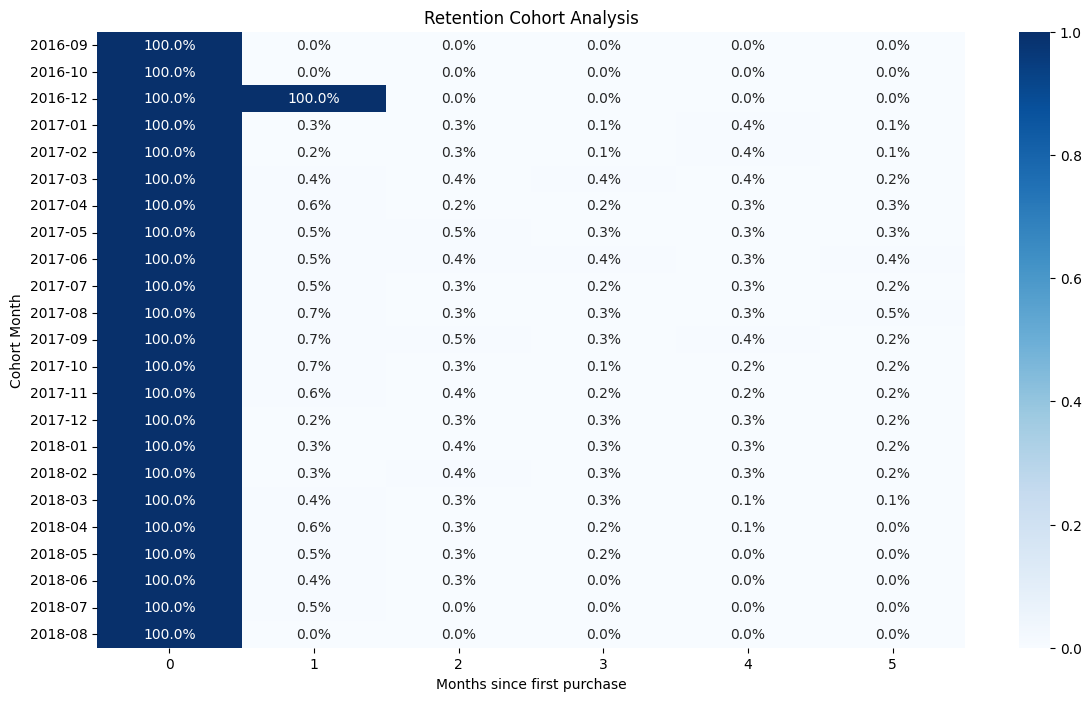

In [59]:
df = order_fact[order_fact['order_status'] == 'delivered'].copy()

first_purchase = df.groupby('customer_unique_id', as_index=False)['order_purchase_timestamp'].min()
first_purchase.columns = ['customer_unique_id', 'first_purchase_date']

df = df.merge(first_purchase, on='customer_unique_id', how='left')

df['cohort_month'] = df['first_purchase_date'].dt.to_period('M')
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

df['cohort_index'] = (
    (df['order_month'] - df['cohort_month'])
    .apply(lambda x: x.n)
)

cohort_data = df.groupby(['cohort_month', 'cohort_index']).agg(
    n_users=('customer_unique_id', 'nunique')
).reset_index()

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='n_users'
)

cohort_size = cohort_pivot[0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention = retention.fillna(0)

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention.iloc[:, :6],
    annot=True,
    fmt=".1%",
    cmap="Blues"
)

plt.title("Retention Cohort Analysis")
plt.ylabel("Cohort Month")
plt.xlabel("Months since first purchase")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

In [60]:
orders_per_user = delivered_orders.groupby('customer_unique_id')['order_id'].nunique()

print("Repeat rate:", (orders_per_user > 1).mean())
print(orders_per_user.describe())

# Средняя оценка для заказов вовремя и с опозданием
avg_scores = delivered_orders.groupby('is_late')['avg_review_score'].mean().reset_index()

avg_scores['avg_review_score'] = avg_scores['avg_review_score'].round(2)
avg_scores

Repeat rate: 0.03000278497825575
count    93358.000000
mean         1.033420
std          0.209097
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64


,is_late,avg_review_score
0,False,4.29
1,True,2.46


In [61]:
df = delivered_orders.copy()

df = df.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

# берём первый заказ клиента
first_orders = df.groupby('customer_unique_id', as_index=False).first()

first_orders = first_orders[['customer_unique_id', 'order_purchase_timestamp', 'is_late', 'delivery_days_actual']]

first_orders = first_orders.rename(columns={
    'order_purchase_timestamp': 'first_purchase_date',
    'is_late': 'first_order_late',
    'delivery_days_actual': 'first_delivery_days'
})

df = df.merge(
    first_orders,
    on='customer_unique_id',
    how='left'
)

df['cohort_month'] = df['first_purchase_date'].dt.to_period('M')
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

df['cohort_index'] = (
    (df['order_month'] - df['cohort_month'])
    .apply(lambda x: x.n)
)

cohort_data = df.groupby(['cohort_month', 'cohort_index', 'first_order_late']).agg({
    'customer_unique_id': 'nunique'
}).rename(columns={'customer_unique_id': 'n_users'}).reset_index()

retention = cohort_data.pivot_table(
    index=['cohort_month', 'first_order_late'],
    columns='cohort_index',
    values='n_users',
    fill_value=0
)

cohort_size = retention[0]
retention = retention.div(cohort_size, axis=0)

retention_curve = retention.groupby(level='first_order_late').mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=retention_curve.columns,
    y=retention_curve.loc[False],
    mode='lines+markers',
    name='Первая доставка вовремя',
    line=dict(color='#2ca02c', width=4),
    marker=dict(size=8)
))

fig.add_trace(go.Scatter(
    x=retention_curve.columns,
    y=retention_curve.loc[True],
    mode='lines+markers',
    name='Первая доставка с просрочкой',
    line=dict(color='#d62728', width=4),
    marker=dict(size=8)
))

fig.update_layout(
    title="Retention Curve: влияние качества первой доставки на удержание пользователей",
    xaxis_title="Месяц после первой покупки",
    yaxis_title="Retention Rate (%)",
    yaxis_tickformat=".1%",
    height=650,
    template="plotly_white",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

В рамках анализа был проведён когортный анализ пользователей, сгруппированных по месяцу первой покупки.
В качестве метрики использовался retention — доля пользователей, совершивших повторную покупку в последующие месяцы.

**Основные результаты**
В рамках наблюдаемого периода повторные покупки совершают немногие пользователи.
Анализ показал, что только около 3% клиентов делают повторные заказы. Это значит, что **97% пользователей не возвращаются после первой покупки**.

Качество первой доставки оказывает критическое влияние на удержание.
Пользователи, у которых первая **доставка пришла вовремя**, возвращаются в следующем месяце **в 10 раз чаще**, чем те, кто столкнулся с просрочкой:

Первая доставка *вовремя → 5.0%* retention на 1-й месяц.

Первая доставка *с просрочкой → 0.5%* retention на 1-й месяц

Начиная со 2–3 месяца retention в обеих группах резко падает и стабилизируется на уровне 0.1–0.4%.
Дальнейшая разница между группами становится статистически незначимой.

**Рекомендации**
Так как мы доказали, что качество доставки напрямую влияет на удержание пользователей, будем идти от того, что нужно улучшать данную метрику.
В первую очередь выполнять рекомендации из Гипотезы 4, а также из Гипотезы 2.